# Building a strain from scratch — `ov.synbio` layer A end to end

The previous synbio tutorials all start from a model that already exists. This one starts from the situation industrial work actually begins in: **an organism BiGG has no model for**, and a target it does not currently make.

The chain is: reconstruct → gap-fill → validate → constrain with measured omics → predict knockouts honestly → derive the interventions → check thermodynamics and the proteome budget → and finally hand the pathway over to layer B by asking which enzyme runs each step.

Every input here is real: BiGG's *E. coli* core model, a published *E. coli* protein-abundance table, and the model's own gene-protein-reaction rules.


## 0 — Setup

Weights and cached models are relocatable — on a shared cluster you do not want either landing in `$HOME`.


In [1]:
import os

os.environ.setdefault('OMICOS_SYNBIO_GEM_DIR', os.path.expanduser('~/.omicverse/synbio_gems'))
import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1


## 1 — Reconstruct a model for an organism that has none

`load_gem` can only read a model somebody already built. `reconstruct_gem` builds one.

The default `method='homology'` transfers a template GEM through reciprocal best hits: for every template reaction it asks whether the target organism still has the genes the reaction's GPR requires, and carves away the ones it does not. `method='carveme'` and `method='modelseed'` drive the real external reconstructors when they are installed.

To make the mechanism visible without a proteome download, we pass `proteome=None` and hand it the gene mapping directly — this is the same input the alignment step produces. `proteome=None` is required here: when a path is given it must point at a real file even though `gene_map` skips the alignment, so that a reconstruction can always be traced back to the sequences it came from. Here the "new strain" is one that has lost 40 of the template's genes.


In [2]:
template = ov.synbio.load_gem('textbook')
template_genes = sorted(g.id for g in template.genes)
gene_map = {f'strainX_{g}': g for g in template_genes[:-40]}
print(f'{len(template.reactions)} reactions, {len(template_genes)} genes in the template')


INFO:cobra.io.web.load:Attempting to fetch 'textbook' from the Cobrapy repository.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


95 reactions, 137 genes in the template


In [3]:
draft = ov.synbio.reconstruct_gem(None, template=template, gene_map=gene_map)
print(draft)
print('carved away:', len(draft.dropped_reactions), 'reactions')


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


ReconstructionReport(homology, template='e_coli_core', 77/95 rxns (81%), 110 genes, growth=0.0000)
carved away: 18 reactions


`coverage` is the fraction of the template retained, and `grows` is the question that matters. A carved draft usually **cannot grow** — losing consecutive steps of a pathway breaks it — which is exactly what gap-filling is for.


In [4]:
print('coverage:', f'{draft.coverage:.0%}')
print('grows:', draft.grows, '| growth =', round(draft.growth, 4))


coverage: 81%
grows: False | growth = 0.0


## 2 — Gap-filling

Gap-filling pulls the smallest set of reactions from a universal database that restores flux through the objective.

`method='cobra'` is COBRApy's MILP and finds a genuinely minimal set. `method='lp'` is an L1 relaxation: add every candidate, require growth, minimise the total flux they carry, then prune. It needs only an LP solver, and — importantly — it handles gaps that need **several reactions at once**, which the obvious "add whichever single reaction helps most, repeat" cannot, because no single addition moves growth off zero.


In [5]:
universe = ov.synbio.universal_reactions([template])
filled = ov.synbio.gapfill_model(draft.model, universe=universe, method='lp',
                                 growth_threshold=0.05)
print(filled)
print('added:', filled.added)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


GapfillReport(lp, +4 rxns, growth 0.0000 -> 0.3711)
added: ['PPC', 'O2t', 'PGI', 'TPI']


## 3 — Validating the draft

Before trusting a reconstruction: does mass and charge balance, are there dead-end metabolites, and — the one that catches gap-filling artefacts — can the model make ATP with every uptake shut off? A positive `energy_leak` means a thermodynamically impossible cycle got added.


In [6]:
qc = ov.synbio.validate_gem(filled.model, check_blocked=False)
print('grows:', qc['grows'], '| unbalanced reactions:', len(qc['unbalanced']))
print('ATP from nothing (energy leak):', qc['energy_leak'])


grows: True | unbalanced reactions: 0
ATP from nothing (energy leak): 0.0


(<Figure size 1008x272 with 3 Axes>,
 [<Axes: title={'center': 'homology: 81% of template retained'}, ylabel='reactions'>,
  <Axes: title={'center': 'template genes with a homolog'}>,
  <Axes: title={'center': 'gap-filling'}, ylabel='growth (1/h)'>])

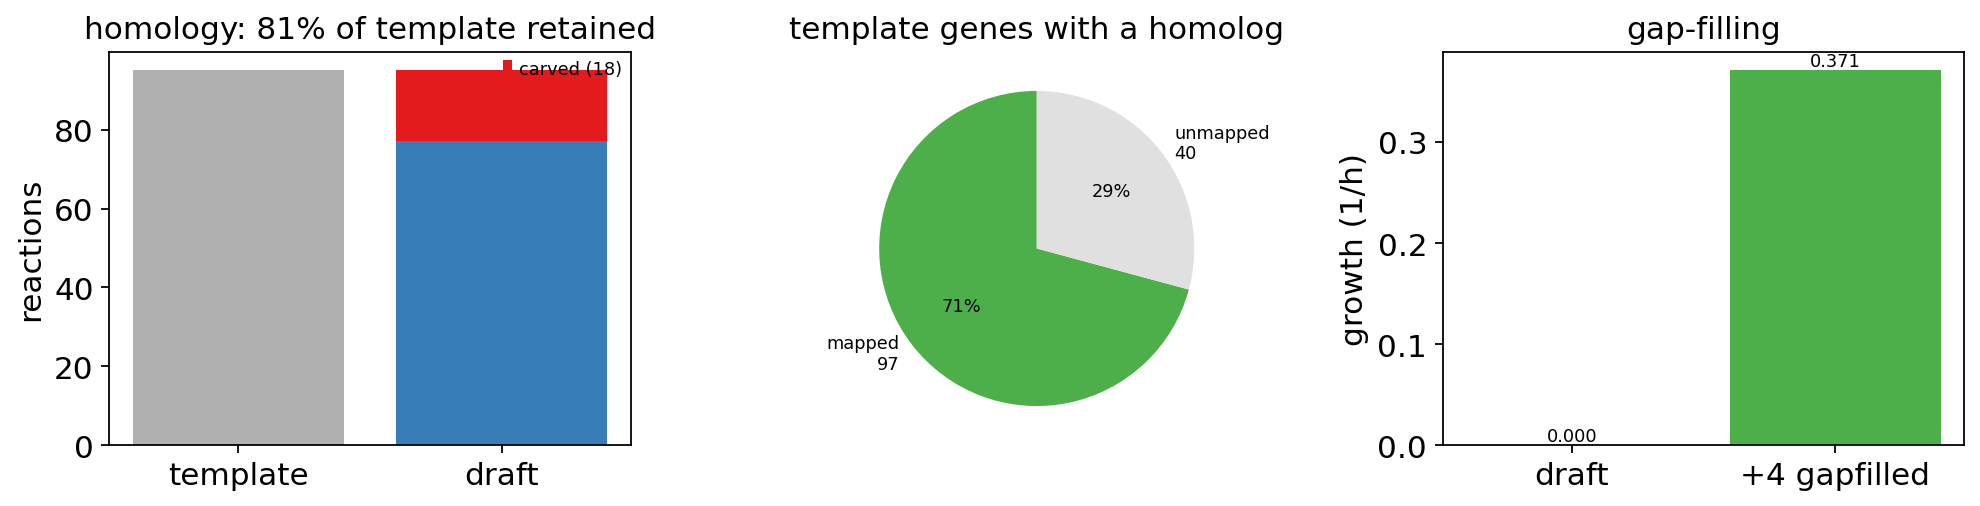

In [7]:
ov.synbio.plot_reconstruction(draft, gapfill=filled)


## 4 — The Learn → Design bridge: constraining the model with measured omics

This is the join that did not exist. `ov.bulk` / `ov.single` produce expression; `ov.synbio` holds a genome-scale model; nothing connected them. The GEM answered *what could this organism do*, the omics answered *what is it doing*, and neither answered the useful question — **what can these cells, in this state, do**.

`fetch_ecoli_abundance` returns a real published *E. coli* protein-abundance table keyed by b-number, which is the identifier BiGG genes already use — so it drops in without an id-mapping step, which is where most omics-to-GEM attempts actually fail.


In [8]:
abundance = ov.synbio.fetch_ecoli_abundance()
rxn_expr = ov.synbio.reaction_expression(abundance, template)
measured = sum(v is not None for v in rxn_expr.values())
print(f'{len(abundance)} genes measured; {measured}/{len(rxn_expr)} reactions got a value')


4097 genes measured; 66/95 reactions got a value


Genes are folded onto reactions through the GPR with the standard convention: **`and` takes the minimum** (a complex runs no faster than its scarcest subunit) and **`or` takes the maximum** (isozymes are alternatives). A reaction nobody measured stays `None`, which is deliberately distinct from measuring zero.

Four published methods are available. GIMME and RIPTiDe are pure LP; iMAT and tINIT are MILP and need no objective function at all — which makes iMAT the one to reach for when you do not know what the cells are optimising, i.e. most of the time outside exponential-phase batch culture.


In [9]:
gimme = ov.synbio.contextualize_gem(abundance, template, method='gimme')
riptide = ov.synbio.contextualize_gem(abundance, template, method='riptide')
imat = ov.synbio.contextualize_gem(abundance, template, method='imat', time_limit=30)
for r in (gimme, riptide, imat):
    print(r)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


ContextResult(gimme, 50 active rxns, objective=0.8739, inconsistency=5546.288)
ContextResult(riptide, 52 active rxns, objective=0.8739)
ContextResult(imat, 48 active rxns, objective=0.8739, agreement=0.941)


`objective_value` means the same thing for every method — the biological objective of the contextualised model. The method's own fit lives in `inconsistency` (GIMME: how much poorly-supported flux the required function still forced) or `agreement` (iMAT: the fraction of expression calls the flux distribution satisfied).


(<Figure size 1008x272 with 3 Axes>,
 [<Axes: title={'center': 'expression mapped through GPRs'}, xlabel='reaction expression', ylabel='reactions'>,
  <Axes: title={'center': 'imat  (agreement 0.941)'}, ylabel='reactions'>,
  <Axes: title={'center': 'expression vs |flux|  (r = 0.03)'}, xlabel='reaction expression', ylabel='|flux|'>])

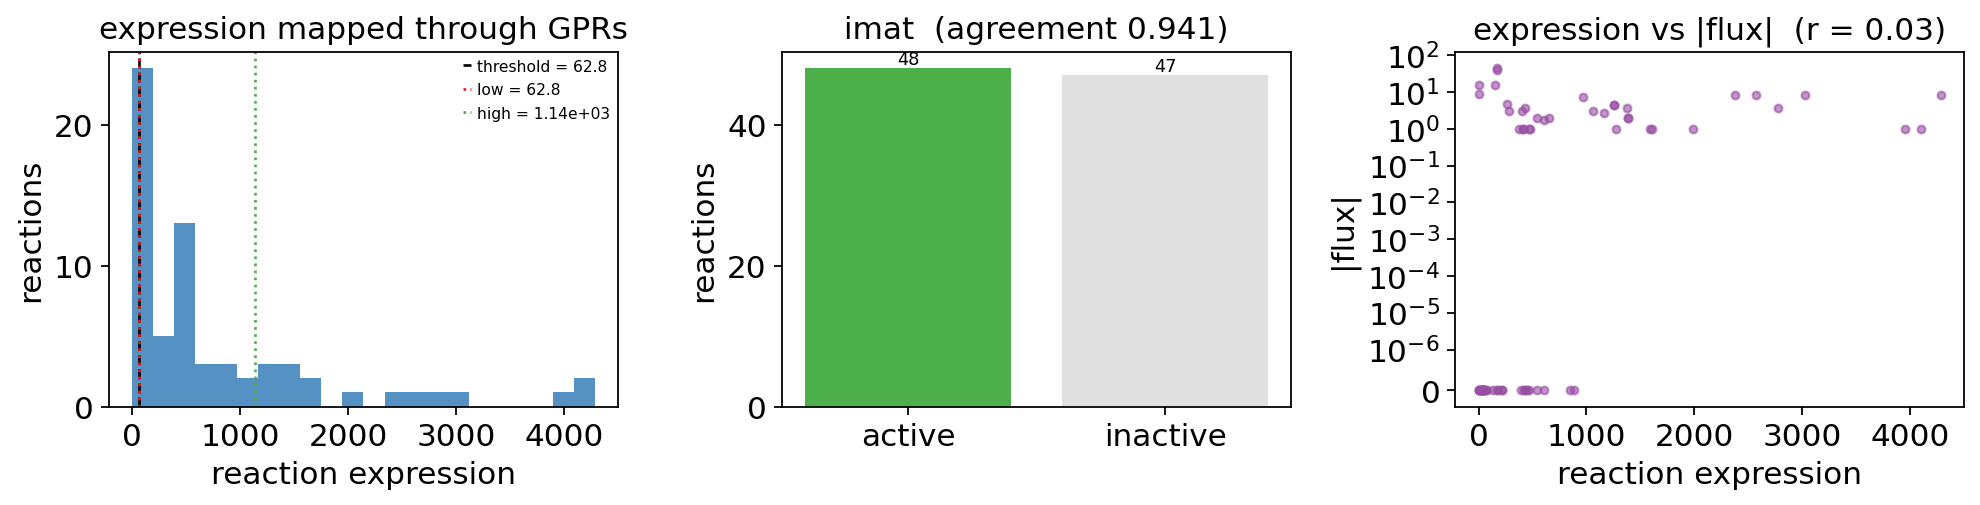

In [10]:
ov.synbio.plot_contextualization(imat)


In [11]:
df = gimme.to_frame().sort_values('expression', ascending=False)
print(df.head(8))


          expression       flux  active
reaction                               
GAPD          4285.0  17.909169    True
MDH           4096.0   4.719406    True
ICL           3954.0   0.000000   False
PGK           3022.0 -17.909169    True
TPI           2772.0   9.217639    True
ENO           2567.0  16.732521    True
PGM           2376.0 -16.732521    True
ICDHyr        1988.0   5.567993    True


## 5 — Knockouts, honestly

Plain FBA answers *given this deletion, what is the best the network could possibly do*. A cell that just lost a gene is not that cell — it still carries the wild-type proteome and lands on the **nearest** feasible flux state, not the globally optimal one.

The difference is not subtle. On this model, deleting `PFK`:


In [12]:
comparison = ov.synbio.compare_knockout_methods(template, ['PFK'])
print(comparison[['growth', 'growth_ratio', 'n_changed']])


               growth  growth_ratio  n_changed
method                                        
fba          0.704037      0.805607         53
linear_moma  0.000000      0.000000         48
room         0.239732      0.274317         47


FBA calls it a viable strain at 81% of wild-type growth. MOMA calls it dead. **FBA does not merely overestimate the knockout — it inverts the call**, and a knockout screen run on FBA alone will keep targets that are actually lethal.

The methods agree where they should: `ENO` is genuinely essential and all three report zero, while `PGI` is dispensable and all three keep it alive — so MOMA is not simply pessimistic.


In [13]:
for reaction in ('ENO', 'PGI'):
    row = ov.synbio.compare_knockout_methods(template, [reaction])['growth']
    print(reaction, dict(row.round(4)))


ENO {'fba': np.float64(0.0), 'linear_moma': np.float64(0.0), 'room': np.float64(0.0)}


PGI {'fba': np.float64(0.8632), 'linear_moma': np.float64(0.8426), 'room': np.float64(0.7465)}


(<Figure size 688x272 with 2 Axes>,
 [<Axes: title={'center': 'red = FBA (re-optimises freely)'}, ylabel='post-knockout growth (1/h)'>,
  <Axes: title={'center': 'extent of rewiring'}, ylabel='reactions whose flux moved'>])

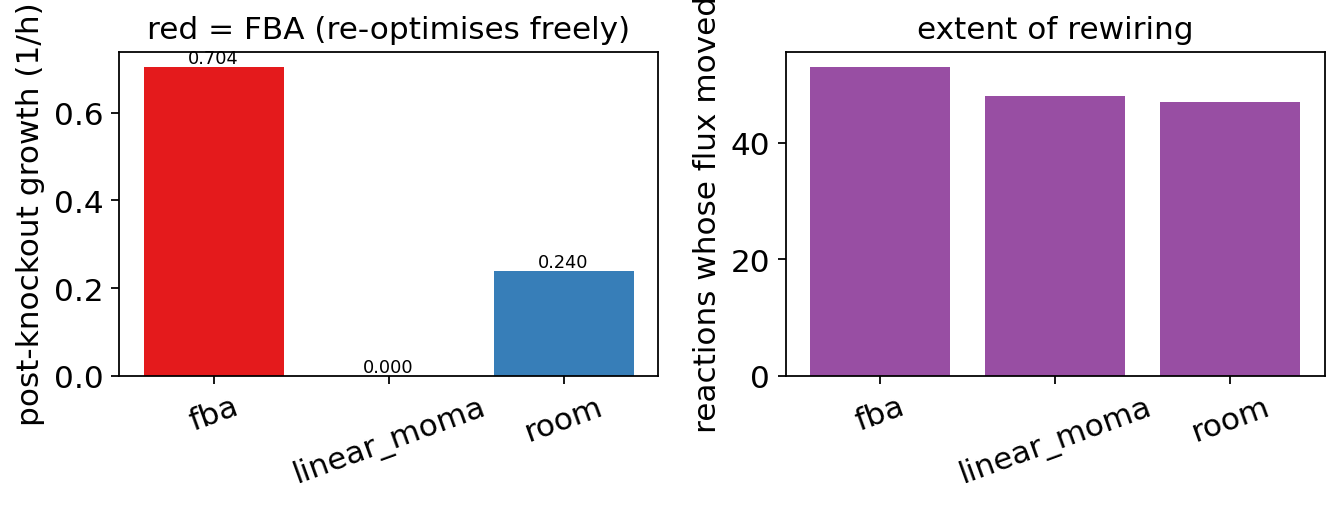

In [14]:
ov.synbio.plot_knockout_response(comparison)


`compare_knockout_methods` is the summary; `knockout_flux` is the single run behind each row, and it keeps the method's own objective separate from growth. Linear MOMA's `objective_value` is a *flux deviation* (~71 here), not a growth rate — reading one as the other silently mixes units, so they live in different fields.


In [15]:
detail = ov.synbio.knockout_flux(template, ['PGI'], method='linear_moma')
print(detail)
print('method objective:', round(detail.method_objective, 2), '=', detail.method_objective_meaning)


PerturbationResult(linear_moma, ko=['PGI'], growth=0.8426 (96% of wt), 47 fluxes moved)
method objective: 70.96 = total absolute flux deviation from wild type


## 6 — Which fluxes *must* change: OptForce

`strain_design` already covers OptKnock, RobustKnock and minimal cut sets. OptForce asks a different question: comparing the flux ranges the wild type can occupy against the ranges an over-producing strain must occupy, **which reactions cannot stay where they are?**

The MUST sets are derived, not guessed — a reaction is in them exactly when the two intervals do not overlap. The FORCE set on top is an explicit search, and `force_is_exact` says so.


In [16]:
force = ov.synbio.optforce(template, 'EX_succ_e', target_fraction=0.8,
                           max_interventions=3)
print(force)
print('FORCE set:', force.force)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


...

INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


OptForceResult(target='EX_succ_e', MUST↑4 MUST↓10, FORCE=1, guaranteed=8.664)
FORCE set: [down(FUM: [-0.513,8.05] -> [-10.3,-8.66])]


On this model the search picks **reversing fumarase**, which is the textbook route to succinate over-production in *E. coli*, and guaranteed product goes from 0 to 8.7.


(<Figure size 880x320 with 2 Axes>,
 [<Axes: title={'center': 'grey = wild type, blue = required, red = in FORCE set'}, xlabel='flux range'>,
  <Axes: title={'center': 'growth-coupled yield'}, ylabel='guaranteed product flux'>])

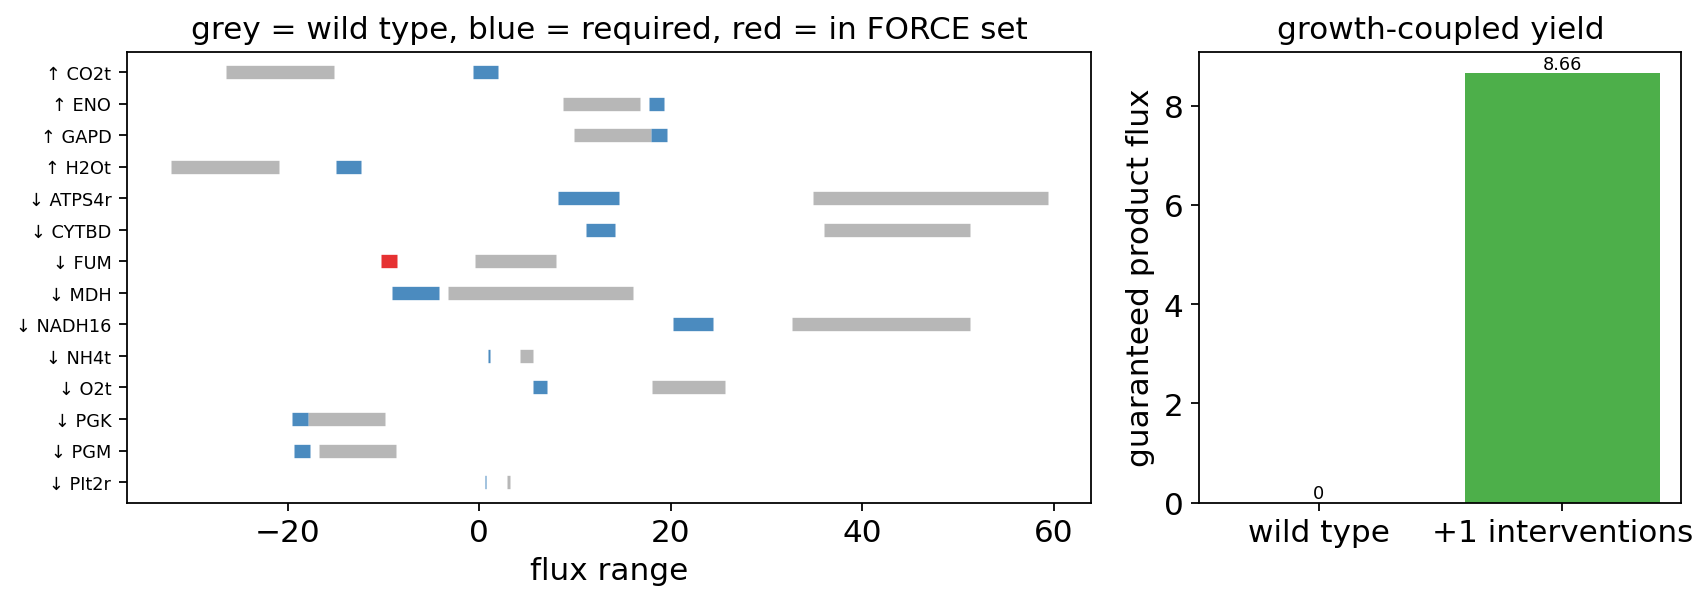

In [17]:
ov.synbio.plot_optforce(force)


## 7 — Thermodynamics as a constraint, not a footnote

`reaction_dg` and `max_min_driving_force` compute ΔG *beside* FBA. `thermo_fba` puts it inside.

`method='directionality'` is pure LP: derive each reaction's ΔG′ interval over the allowed concentration box and close off any direction the interval forbids. `method='tmfa'` is the full Henry-2007 MILP, where directions and concentrations are chosen together — which is what removes thermodynamically infeasible internal loops that the per-reaction test cannot see.


In [18]:
thermo = ov.synbio.thermo_fba(template, method='directionality')
print(thermo)
print('directions closed off:', thermo.blocked_forward + thermo.blocked_reverse)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


ThermoFBAResult(directionality, objective=0.8739 vs 0.8739 unconstrained (-0.0% cost), 1 reactions constrained)
directions closed off: ['GLCpts']


(<Figure size 880x320 with 2 Axes>,
 [<Axes: title={'center': '-0.0% of the objective was infeasible'}, ylabel='objective'>,
  <Axes: title={'center': 'red = a direction was closed off'}, xlabel='ΔG′ interval over the concentration box (kJ/mol)'>])

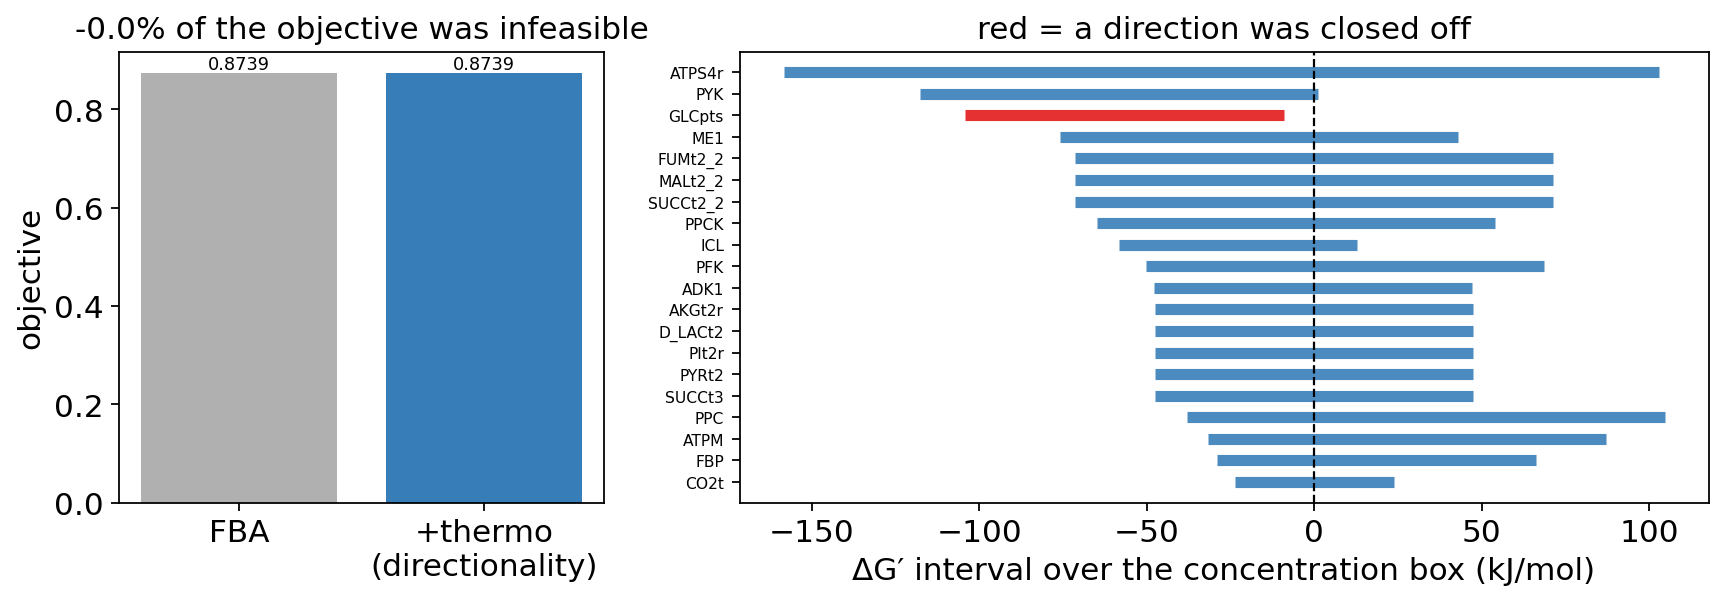

In [19]:
ov.synbio.plot_thermo_fba(thermo)


## 8 — Paying for the proteome

`ec_model` charges reactions against a shared enzyme pool. RBA goes one step further and makes the **ribosome** a constrained resource too, so growth has to pay for synthesising the enzymes it uses. That is the mechanism behind overflow metabolism: a cell excretes acetate at high glucose not because it cannot oxidise it, but because respiration costs more protein per ATP than fermentation does.


In [20]:
loose = ov.synbio.rba(template, total_protein=0.9)
tight = ov.synbio.rba(template, total_protein=0.05)
print('budget 0.9 :', loose)
print('budget 0.05:', tight)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


budget 0.9 : RBAResult(growth=0.8739 vs 0.8739 unconstrained, ribosome 97.1% of proteome)
budget 0.05: RBAResult(growth=0.7421 vs 0.8739 unconstrained, ribosome 97.2% of proteome)


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


(<Figure size 800x288 with 2 Axes>,
 [<Axes: title={'center': 'growth is proteome-limited below the plateau'}, xlabel='proteome budget (g protein / gDW)', ylabel='growth (1/h)'>,
  <Axes: title={'center': 'where the budget goes'}, xlabel='proteome budget', ylabel='fraction of used protein'>])

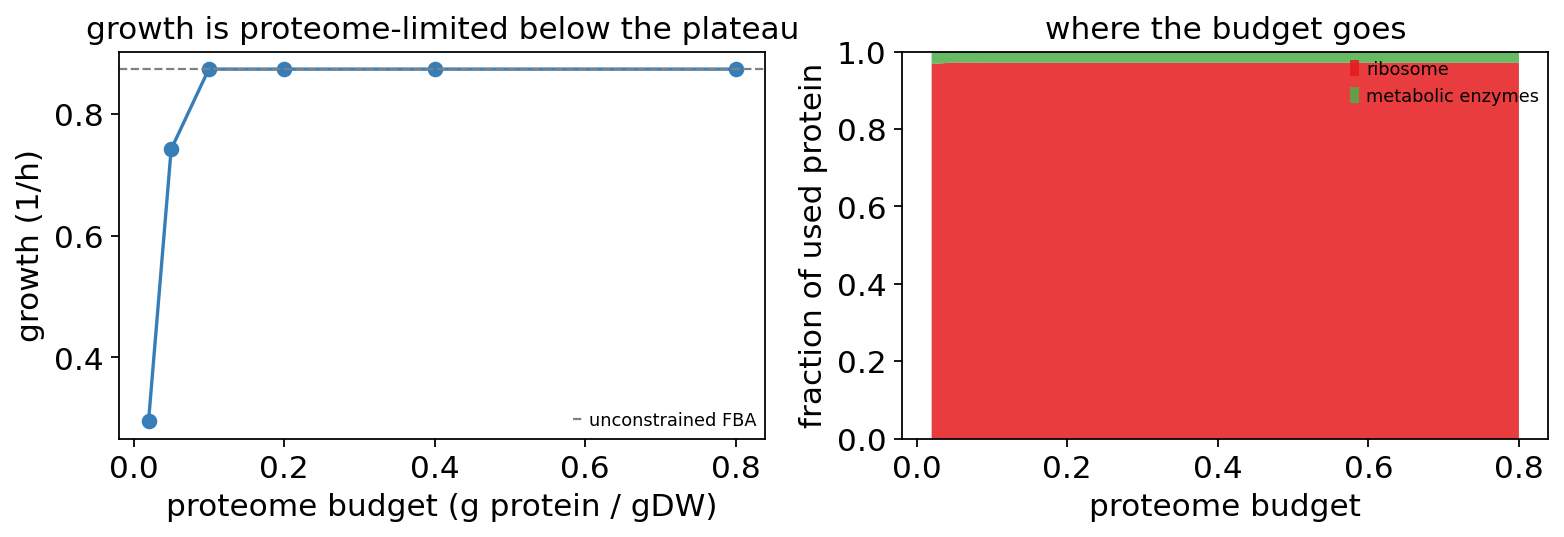

In [21]:
ov.synbio.plot_rba(template, budgets=[0.02, 0.05, 0.1, 0.2, 0.4, 0.8])


## 9 — More than one organism in the flask

`community_model` merges GEMs into one compartmentalised model with a **shared** medium, so cross-feeding is a computed flux rather than an assumption. The uptake bounds of the shared exchanges inherit the tightest member's — with an unlimited medium the members never compete, and the abundance question becomes vacuous.

`steadycom` then finds the composition at which every member grows at the *same* rate, which is the only self-consistent steady state for a co-culture.


In [22]:
community = ov.synbio.community_model({'a': template, 'b': template.copy()})
result = ov.synbio.steadycom(community)
print(result)
print('abundances:', {k: round(v, 3) for k, v in result.abundances.items()})


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


INFO:cobra.core.model:The current solver interface glpk doesn't support setting the optimality tolerance.


CommunityResult(steadycom, 2 members, community growth=0.8312, 0 cross-feeding links)
abundances: {'a': 0.895, 'b': 0.105}


(<Figure size 880x288 with 2 Axes>,
 [<Axes: title={'center': 'community growth 0.8312 /h (steadycom)'}, ylabel='relative abundance'>,
  <Axes: title={'center': 'cross-feeding'}>])

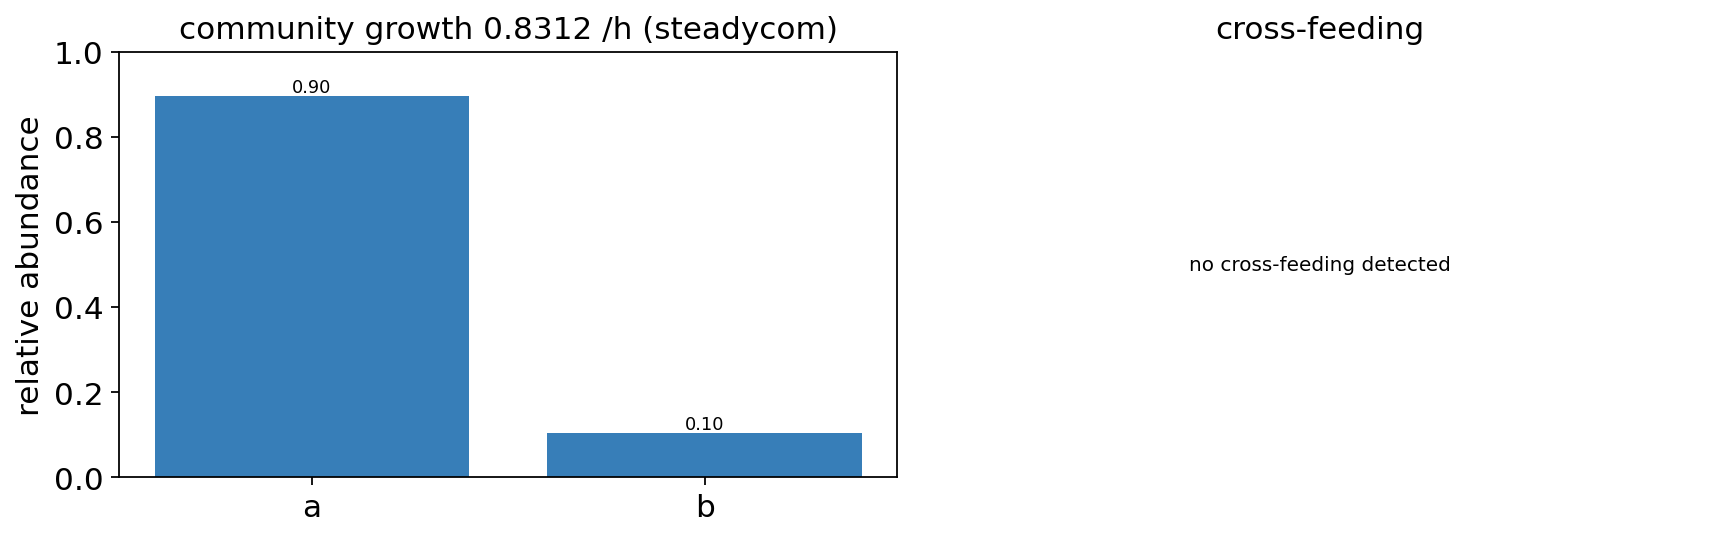

In [23]:
ov.synbio.plot_community(result)


Two identical members have **no determined ratio** — with the abundances summing to one, every split is feasible — and the result says so rather than presenting an arbitrary vertex as a prediction.


In [24]:
print('composition is unique:', result.abundance_is_unique)
for note in result.notes:
    print(note)


composition is unique: False
丰度分布不唯一:在同一群落生长率下存在多种可行组成(成员可互换或代谢冗余时必然如此)。这里给出的是其中一个顶点,不要当作预测的组成。


## 10 — Handing the pathway to layer B

`pathway_search` and `retro_biosynthesis` produce chemical transformations. Somebody then had to decide, by hand, which enzyme performs each step. `match_enzymes` closes that joint: give it a reaction and it returns ranked candidates **with sequences**, so the next call is a layer-B function rather than a literature search.

Sources are a local FASTA, the model's own genes, or UniProt (network opt-in). Nothing is bundled — an enzyme database shipped inside an analysis package is stale the day it is written.


In [25]:
match = ov.synbio.match_enzymes('PFK', model=template)
print(match)
print('candidates:', [c.identifier for c in match.candidates])


EnzymeMatch('PFK', EC='', 2 candidates, 0 with sequences)
candidates: ['b1723', 'b3916']


For a whole route, `match_pathway_enzymes` runs the same thing per step and reports which steps have **no** candidate — those gaps are the engineering risk, and they are what a coverage number hides.


In [26]:
route = ov.synbio.match_pathway_enzymes(['PFK', 'PGI', 'NOT_A_REACTION'], model=template)
print('coverage:', f"{route['coverage']:.0%}", '| gaps:', route['gaps'])


coverage: 67% | gaps: ['NOT_A_REACTION']


(<Figure size 352x272 with 1 Axes>,
 <Axes: title={'center': '2/3 steps have a candidate — 1 gaps (red)'}, ylabel='candidate enzymes'>)

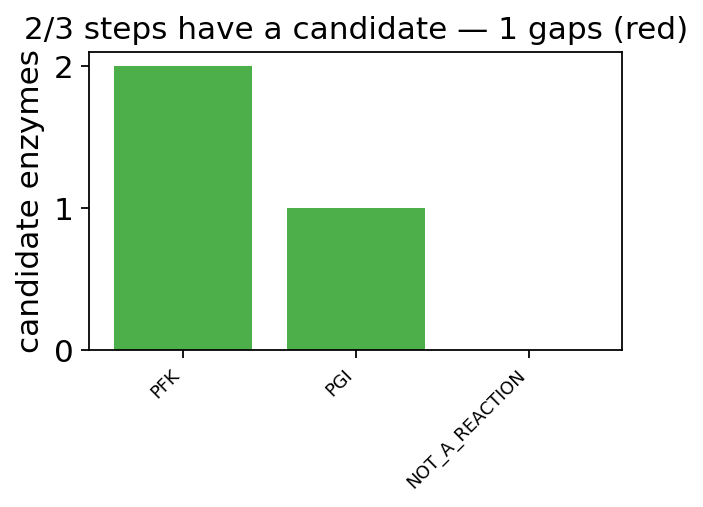

In [27]:
ov.synbio.plot_enzyme_match(route)


Two further layer-A functions are reachable but not exercised here because each needs a dependency this notebook does not assume: `ov.synbio.micom_grow` solves the same community with MICOM's cooperative-tradeoff objective (a different modelling assumption from SteadyCom's strict equal-growth — running both and comparing is the point), and `ov.synbio.me_model` loads a COBRAme metabolism-and-expression reconstruction, which writes transcription and translation down as explicit reactions rather than as the single aggregate budget `rba` imposes.


From here the layer-B chain is available on each candidate — `enzyme_kcat`, `enzyme_km`, `predict_solubility`, `predict_expression_level` — and a better `k_cat` feeds straight back into `ec_model` and re-solves the yield. That round trip is the subject of the next tutorial.
